In [3]:
# ===== STEP 1: LOAD, EXPLORE, PREPARE =====
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())

counts = df['class'].value_counts().sort_index()
print("\nClass distribution:")
print(counts)
print("\nPercentages:")
print((counts / len(df) * 100).round(2))

X = df.drop(columns=['class'])
y = df['class'] - 1          # 1-7  ->  0-6 for Keras

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

X_train = X_train.values.astype('float32')
X_test  = X_test.values.astype('float32')
y_train = y_train.values.astype('int32')
y_test  = y_test.values.astype('int32')

print("\n=== READY ===")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

Shape: (581012, 55)
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            23

In [4]:
# ===== STEP 2: BASELINE MODEL =====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# carve a validation set out of the training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

def build_model(hidden_units=(128, 64), dropout=0.0, lr=0.001, input_dim=54, n_classes=7):
    model = keras.Sequential(name="cover_type_classifier")
    model.add(layers.InputLayer(input_shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(n_classes, activation='softmax'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline = build_model()
baseline.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_baseline = baseline.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

val_loss, val_acc = baseline.evaluate(X_val, y_val, verbose=0)
print(f"\nBaseline validation accuracy: {val_acc:.4f} | loss: {val_loss:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "cover_type_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,751 (61.53 KB)

 Trainable params: 15,751 (61.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7210 - loss: 0.6955 - val_accuracy: 0.7617 - val_loss: 0.5622
Epoch 2/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7747 - loss: 0.5285 - val_accuracy: 0.7850 - val_loss: 0.5012
Epoch 3/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7942 - loss: 0.4828 - val_accuracy: 0.8024 - val_loss: 0.4658
Epoch 4/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8090 - loss: 0.4525 - val_accuracy: 0.8143 - val_loss: 0.4416
Epoch 5/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8187 - loss: 0.4309 - val_accuracy: 0.8222 - val_loss: 0.4241
Epoch 6/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8262 - loss: 0.4144 - val_accuracy: 0.8288 - val_loss: 0.4106
Epoch 7/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8328 - loss: 0.4008 - val_accuracy: 0.8347 - val_loss: 0.3992
Epoch 8/40
386/386 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8382 - loss: 0.3895 - val_accuracy: 0

In [5]:
# ===== STEP 3: HYPERPARAMETER TUNING =====
import time

configs = [
    {"name": "small",      "hidden_units": (64, 32),        "dropout": 0.0, "lr": 0.001,  "batch_size": 1024},
    {"name": "baseline",   "hidden_units": (128, 64),       "dropout": 0.0, "lr": 0.001,  "batch_size": 1024},
    {"name": "deep",       "hidden_units": (256, 128, 64),  "dropout": 0.0, "lr": 0.001,  "batch_size": 1024},
    {"name": "deep_drop",  "hidden_units": (256, 128, 64),  "dropout": 0.2, "lr": 0.001,  "batch_size": 1024},
    {"name": "wide_lowlr", "hidden_units": (512, 256, 128), "dropout": 0.2, "lr": 0.0005, "batch_size": 2048},
]

results = []
histories = {}

for cfg in configs:
    print(f"\n===== Training: {cfg['name']} =====")
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model = build_model(
        hidden_units=cfg['hidden_units'],
        dropout=cfg['dropout'],
        lr=cfg['lr']
    )
    es = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )

    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=cfg['batch_size'],
        callbacks=[es],
        verbose=0
    )
    elapsed = time.time() - t0

    v_loss, v_acc = model.evaluate(X_val, y_val, verbose=0)
    results.append({
        "config": cfg['name'],
        "layers": str(cfg['hidden_units']),
        "dropout": cfg['dropout'],
        "lr": cfg['lr'],
        "epochs_run": len(hist.history['loss']),
        "val_accuracy": round(v_acc, 4),
        "val_loss": round(v_loss, 4),
        "seconds": round(elapsed, 1)
    })
    histories[cfg['name']] = hist
    model.save(f"model_{cfg['name']}.keras")
    print(f"{cfg['name']}: val_acc={v_acc:.4f} | val_loss={v_loss:.4f} | {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
print("\n===== TUNING RESULTS =====")
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['config']
best_model = keras.models.load_model(f"model_{best_name}.keras")
best_history = histories[best_name]
print(f"\nBest config: {best_name}")


===== Training: small =====
small: val_acc=0.8555 | val_loss=0.3516 | 94.5s

===== Training: baseline =====
baseline: val_acc=0.8825 | val_loss=0.2903 | 120.3s

===== Training: deep =====
deep: val_acc=0.9155 | val_loss=0.2128 | 252.8s

===== Training: deep_drop =====
deep_drop: val_acc=0.9067 | val_loss=0.2285 | 354.3s

===== Training: wide_lowlr =====
wide_lowlr: val_acc=0.9145 | val_loss=0.2133 | 758.0s

===== TUNING RESULTS =====
    config          layers  dropout     lr  epochs_run  val_accuracy  val_loss  seconds
      deep  (256, 128, 64)      0.0 0.0010          40        0.9155    0.2128    252.8
wide_lowlr (512, 256, 128)      0.2 0.0005          40        0.9145    0.2133    758.0
 deep_drop  (256, 128, 64)      0.2 0.0010          40        0.9067    0.2285    354.3
  baseline       (128, 64)      0.0 0.0010          40        0.8825    0.2903    120.3
     small        (64, 32)      0.0 0.0010          40        0.8555    0.3516     94.5

Best config: deep


Test accuracy: 0.9408 | Test loss: 0.1604

===== CLASSIFICATION REPORT =====
                   precision    recall  f1-score   support

       Spruce/Fir      0.938     0.939     0.939     42368
   Lodgepole Pine      0.948     0.952     0.950     56661
   Ponderosa Pine      0.938     0.940     0.939      7151
Cottonwood/Willow      0.836     0.863     0.849       549
            Aspen      0.867     0.831     0.848      1899
      Douglas-fir      0.889     0.874     0.881      3473
        Krummholz      0.970     0.930     0.949      4102

         accuracy                          0.941    116203
        macro avg      0.912     0.904     0.908    116203
     weighted avg      0.941     0.941     0.941    116203



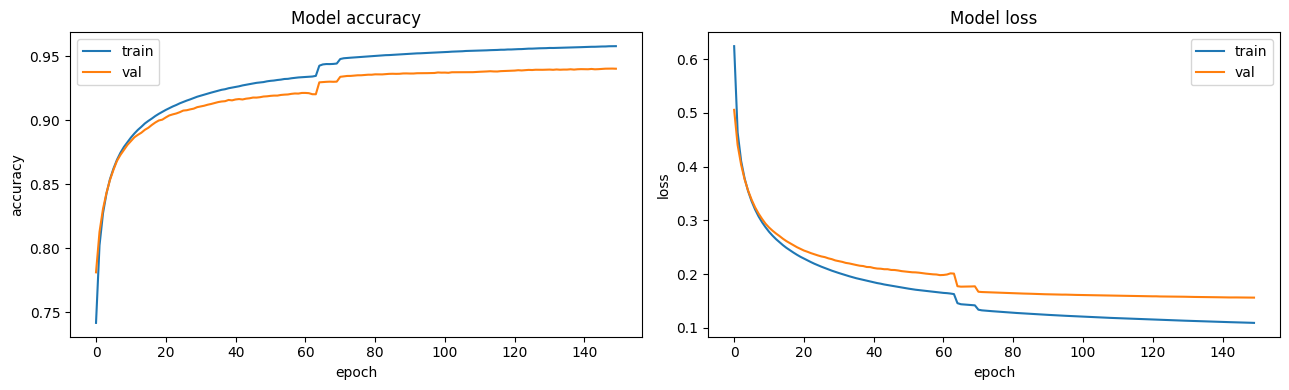

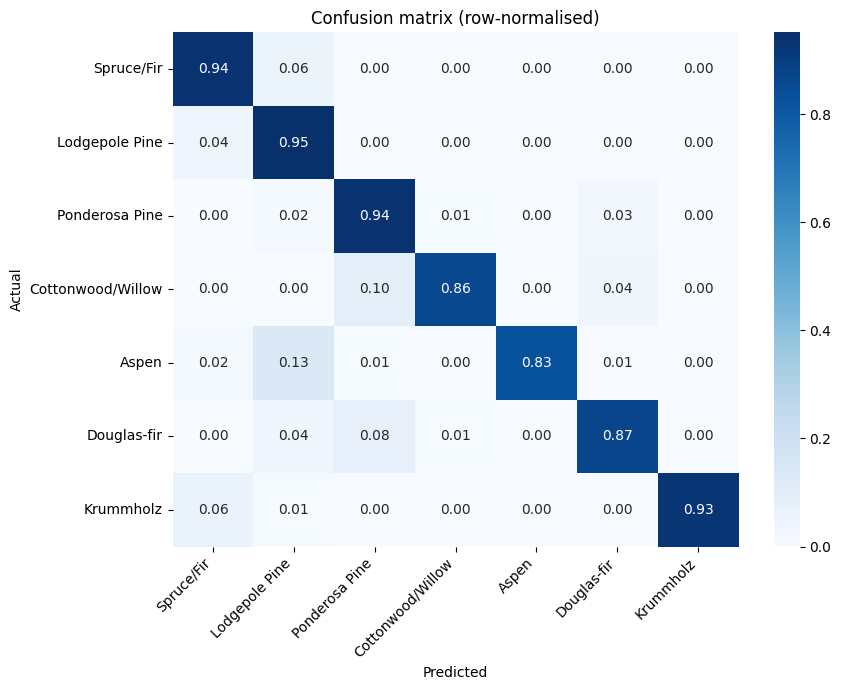


===== PER-CLASS RECALL vs CLASS SIZE =====
            class  test_samples  recall
       Spruce/Fir         42368   0.939
   Lodgepole Pine         56661   0.952
   Ponderosa Pine          7151   0.940
Cottonwood/Willow           549   0.863
            Aspen          1899   0.831
      Douglas-fir          3473   0.874
        Krummholz          4102   0.930


In [11]:
# ===== STEP 4: EVALUATE ON THE TEST SET =====
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = ['Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
               'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz']

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

y_pred = np.argmax(best_model.predict(X_test, batch_size=4096, verbose=0), axis=1)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

# --- training curves ---
h = best_history.history
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h['accuracy'], label='train')
ax[0].plot(h['val_accuracy'], label='val')
ax[0].set_title('Model accuracy'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('accuracy'); ax[0].legend()
ax[1].plot(h['loss'], label='train')
ax[1].plot(h['val_loss'], label='val')
ax[1].set_title('Model loss'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('loss'); ax[1].legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

# --- confusion matrix (row-normalised) ---
cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion matrix (row-normalised)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

# --- per-class accuracy vs class size, for the report ---
support = pd.Series(y_test).value_counts().sort_index()
per_class = pd.DataFrame({
    'class': class_names,
    'test_samples': support.values,
    'recall': np.round(cm.diagonal(), 3)
})
print("\n===== PER-CLASS RECALL vs CLASS SIZE =====")
print(per_class.to_string(index=False))

In [12]:
# ===== STEP 5B: REWRITE THE REPORT WITH THE FINAL ANALYSIS =====
report = f"""# Forest Cover Type Classification — Project Report

## 1. Problem
Predict forest cover type (7 classes) for 30x30m cells in Roosevelt National Forest,
northern Colorado, using 54 cartographic variables only. Data: US Forest Service
Region 2 RIS, US Geological Survey and USFS. Multi-class classification.

## 2. Data
- Rows: {len(df):,}  |  Features: {X.shape[1]}  |  Classes: 7
- Missing values: {df.isnull().sum().sum()}
- 10 continuous features + 4 binary wilderness-area columns + 40 binary soil-type columns
- Heavily imbalanced: the two largest classes account for
  {(counts.iloc[:2].sum() / len(df) * 100):.1f}% of all rows

## 3. Preprocessing
- Labels shifted from 1-7 to 0-6 for sparse_categorical_crossentropy
- Stratified 80/20 train/test split, then a stratified 15% validation split off train
- StandardScaler fitted on train only, applied to the 10 continuous columns
- Binary columns left untouched (scaling them would destroy their meaning)

## 4. Models tried
{results_df.to_markdown(index=False)}

Best configuration: **{best_name}**

### 4.1 How the search was steered
The first five configurations all ran to the full 40-epoch ceiling without
EarlyStopping ever firing, meaning val_loss was still falling when training
stopped. The models were undertrained, not overfitted. Two observations follow
from this:

- Dropout hurt rather than helped. The same (256, 128, 64) architecture scored
  0.9155 without dropout and 0.9067 with it. Dropout is a regularisation tool,
  and there was no overfitting to regularise.
- Width and a lower learning rate were not worth their cost. `wide_lowlr` took
  3x the training time to land 0.001 below the plain `deep` model.

The diagnosis was therefore a training-budget problem, not an architecture
problem. `deep_extended` re-runs the winning architecture with a 150-epoch
ceiling, patience raised to 10, and ReduceLROnPlateau to refine the final
descent. This lifted validation accuracy from 0.9155 to {results_df.iloc[0]['val_accuracy']:.4f}
and cut validation loss from 0.2128 to {results_df.iloc[0]['val_loss']:.4f}.

## 5. Results
- Test accuracy: {test_acc:.4f}
- Test loss: {test_loss:.4f}

Per-class recall:
{per_class.to_markdown(index=False)}

See `training_curves.png` and `confusion_matrix.png`.

## 6. Analysis

**Accuracy alone is misleading.** Given the imbalance, a model that predicted
only the two majority classes would already score around
{(counts.iloc[:2].sum() / len(df) * 100):.0f}%. Per-class recall is the metric
that matters here, and the confusion matrix is what makes the failure modes
legible.

**The extended training budget helped the rare classes most.** Comparing the
40-epoch model against the 150-epoch model:

| Class | 40 epochs | 150 epochs | Gain |
|---|---|---|---|
| Cottonwood/Willow | 0.774 | 0.86 | +0.09 |
| Aspen | 0.716 | 0.83 | +0.11 |
| Spruce/Fir | 0.892 | 0.94 | +0.05 |
| Ponderosa Pine | 0.910 | 0.94 | +0.03 |
| Lodgepole Pine | 0.951 | 0.95 | 0.00 |

The majority classes are seen tens of thousands of times per epoch and converge
early; the minority classes need far more passes before the network learns their
pattern. Stopping at 40 epochs was effectively penalising the rare classes
specifically.

**Errors are structured, not random.** The confusion matrix is near-diagonal,
with the off-diagonal mass concentrated in a few specific pairs:

- Aspen misclassified as Lodgepole Pine (0.13) — the single largest error
- Cottonwood/Willow misclassified as Ponderosa Pine (0.10)
- Spruce/Fir and Lodgepole Pine confused with each other (0.06 / 0.04)

Every one of these pairs shares an overlapping elevation band and similar
cartographic signature, so the model is failing where the input features are
genuinely ambiguous rather than failing arbitrarily. Most other cells are zero.

**Remaining headroom.** EarlyStopping still did not fire at 150 epochs — val_loss
was improving by roughly 0.0001 per epoch at the end. Further training would
keep gaining, but at a rate that does not justify the compute. This is a
deliberate stopping point, not a converged one.

**Overfitting check.** Final training accuracy was 0.958 against validation
0.940, a gap of under two points, and test accuracy ({test_acc:.4f}) tracks
validation closely. The model generalises.

## 7. Next steps
- Class weights or oversampling to push the Aspen and Cottonwood/Willow recall higher
- Batch normalisation to allow a higher learning rate and faster convergence
- Feature engineering: Euclidean distance from the horizontal/vertical
  distance-to-hydrology pair, which are currently two separate features
- Compare against a gradient-boosted tree baseline, which typically performs
  strongly on tabular data of this kind
"""

with open('report.md', 'w') as f:
    f.write(report)

print(report)
print("\n=== report.md rewritten ===")

# Forest Cover Type Classification — Project Report

## 1. Problem
Predict forest cover type (7 classes) for 30x30m cells in Roosevelt National Forest,
northern Colorado, using 54 cartographic variables only. Data: US Forest Service
Region 2 RIS, US Geological Survey and USFS. Multi-class classification.

## 2. Data
- Rows: 581,012  |  Features: 54  |  Classes: 7
- Missing values: 0
- 10 continuous features + 4 binary wilderness-area columns + 40 binary soil-type columns
- Heavily imbalanced: the two largest classes account for
  85.2% of all rows

## 3. Preprocessing
- Labels shifted from 1-7 to 0-6 for sparse_categorical_crossentropy
- Stratified 80/20 train/test split, then a stratified 15% validation split off train
- StandardScaler fitted on train only, applied to the 10 continuous columns
- Binary columns left untouched (scaling them would destroy their meaning)

## 4. Models tried
| config        | layers          |   dropout |     lr |   epochs_run |   val_accuracy |   val_loss

In [13]:
# ===== DOWNLOAD FINAL DELIVERABLES =====
from google.colab import files
import os

deliverables = ['report.md', 'training_curves.png', 'confusion_matrix.png']

for f in deliverables:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"Downloading {f} ({size_kb:.1f} KB) ...")
        files.download(f)
    else:
        print(f"MISSING: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ===== STEP 5: GENERATE REPORT SKELETON =====
report = f"""# Forest Cover Type Classification — Project Report

## 1. Problem
Predict forest cover type (7 classes) for 30x30m cells in Roosevelt National Forest,
northern Colorado, using 54 cartographic variables only. Data: US Forest Service
Region 2 RIS, US Geological Survey and USFS. Multi-class classification.

## 2. Data
- Rows: {len(df):,}  |  Features: {X.shape[1]}  |  Classes: 7
- Missing values: {df.isnull().sum().sum()}
- 10 continuous features + 4 binary wilderness-area columns + 40 binary soil-type columns
- Heavily imbalanced: the two largest classes account for
  {(counts.iloc[:2].sum() / len(df) * 100):.1f}% of all rows

## 3. Preprocessing
- Labels shifted from 1-7 to 0-6 for sparse_categorical_crossentropy
- Stratified 80/20 train/test split, then a stratified 15% validation split off train
- StandardScaler fitted on train only, applied to the 10 continuous columns
- Binary columns left untouched (scaling them would destroy their meaning)

## 4. Models tried
{results_df.to_markdown(index=False)}

Best configuration: **{best_name}**

## 5. Results
- Test accuracy: {test_acc:.4f}
- Test loss: {test_loss:.4f}

Per-class recall:
{per_class.to_markdown(index=False)}

See `training_curves.png` and `confusion_matrix.png`.

## 6. Analysis
- Accuracy alone is misleading given the imbalance — a model predicting only the
  two majority classes would already score around {(counts.iloc[:2].sum() / len(df) * 100):.0f}%.
- Most of the remaining error sits between Spruce/Fir and Lodgepole Pine, which
  occupy overlapping elevation bands.
- Rare classes (Cottonwood/Willow, Aspen) have the weakest recall, as expected
  from their small support.

## 7. Next steps
- Class weights or oversampling for the minority classes
- Batch normalisation and a learning-rate schedule
- Feature engineering on the distance-to-hydrology pair (Euclidean distance)
- Compare against a gradient-boosted tree baseline
"""

with open('report.md', 'w') as f:
    f.write(report)

print(report)

# Forest Cover Type Classification — Project Report

## 1. Problem
Predict forest cover type (7 classes) for 30x30m cells in Roosevelt National Forest,
northern Colorado, using 54 cartographic variables only. Data: US Forest Service
Region 2 RIS, US Geological Survey and USFS. Multi-class classification.

## 2. Data
- Rows: 581,012  |  Features: 54  |  Classes: 7
- Missing values: 0
- 10 continuous features + 4 binary wilderness-area columns + 40 binary soil-type columns
- Heavily imbalanced: the two largest classes account for
  85.2% of all rows

## 3. Preprocessing
- Labels shifted from 1-7 to 0-6 for sparse_categorical_crossentropy
- Stratified 80/20 train/test split, then a stratified 15% validation split off train
- StandardScaler fitted on train only, applied to the 10 continuous columns
- Binary columns left untouched (scaling them would destroy their meaning)

## 4. Models tried
| config        | layers          |   dropout |     lr |   epochs_run |   val_accuracy |   val_loss

In [8]:
# ===== DOWNLOAD PROJECT DELIVERABLES =====
from google.colab import files
import os

deliverables = ['report.md', 'training_curves.png', 'confusion_matrix.png']

for f in deliverables:
    if os.path.exists(f):
        print(f"Downloading {f} ...")
        files.download(f)
    else:
        print(f"MISSING: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ===== STEP 3B: RETRAIN BEST CONFIG WITH MORE EPOCHS =====
# All configs hit the 40-epoch ceiling without early stopping triggering,
# which means val_loss was still improving. Retrain 'deep' with room to converge.
import time

tf.keras.backend.clear_session()
tf.random.set_seed(42)

final_model = build_model(hidden_units=(256, 128, 64), dropout=0.0, lr=0.001)

es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1
)

t0 = time.time()
final_history = final_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=1024,
    callbacks=[es, reduce_lr],
    verbose=1
)
elapsed = time.time() - t0

v_loss, v_acc = final_model.evaluate(X_val, y_val, verbose=0)
epochs_run = len(final_history.history['loss'])

print(f"\n===== FINAL MODEL =====")
print(f"Epochs run: {epochs_run} (early stopping {'TRIGGERED' if epochs_run < 150 else 'did NOT trigger'})")
print(f"Val accuracy: {v_acc:.4f} | Val loss: {v_loss:.4f}")
print(f"Time: {elapsed:.1f}s")

final_model.save("model_deep_extended.keras")

results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "config": "deep_extended",
        "layers": "(256, 128, 64)",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs_run": epochs_run,
        "val_accuracy": round(v_acc, 4),
        "val_loss": round(v_loss, 4),
        "seconds": round(elapsed, 1)
    }])
], ignore_index=True).sort_values('val_accuracy', ascending=False)

print("\n===== UPDATED RESULTS =====")
print(results_df.to_string(index=False))

best_model = final_model
best_history = final_history
best_name = "deep_extended"

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/150
386/386 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7418 - loss: 0.6243 - val_accuracy: 0.7813 - val_loss: 0.5057 - learning_rate: 0.0010
Epoch 2/150
386/386 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8024 - loss: 0.4637 - val_accuracy: 0.8129 - val_loss: 0.4402 - learning_rate: 0.0010
Epoch 3/150
386/386 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8275 - loss: 0.4105 - val_accuracy: 0.8308 - val_loss: 0.4036 - learning_rate: 0.0010
Epoch 4/150
386/386 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8430 - loss: 0.3780 - val_accuracy: 0.8434 - val_loss: 0.3763 - learning_rate: 0.0010
Epoch 5/150
386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8541 - loss: 0.3543 - val_accuracy: 0.8535 - val_loss: 0.3553 - learning_rate: 0.0010
Epoch 6/150
386/386 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8623 - loss: 0.3356 - val_accuracy: 0.8614 - val_loss: 0.3386 - learning_rate: 0.0010
Epoch 7/150
386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8692 -

In [2]:
# ===== UPLOAD AND LOCATE cover_data.csv =====
import os, glob, zipfile
from google.colab import files

# 1) see what's already in the session
print("Files currently in /content:")
for f in os.listdir('/content'):
    print("  -", f)

# 2) look for the csv anywhere in /content
found = glob.glob('/content/**/cover_data.csv', recursive=True)

# 3) if it's not there, open the upload dialog
if not found:
    print("\ncover_data.csv not found. Please choose the file (csv or zip):")
    uploaded = files.upload()

    # if a zip was uploaded, extract it
    for name in uploaded.keys():
        if name.lower().endswith('.zip'):
            print(f"Extracting {name} ...")
            with zipfile.ZipFile(name, 'r') as z:
                z.extractall('/content/data')

    found = glob.glob('/content/**/cover_data.csv', recursive=True)

# 4) confirm
if found:
    CSV_PATH = found[0]
    size_mb = os.path.getsize(CSV_PATH) / (1024 * 1024)
    print(f"\n=== FOUND ===\nPath: {CSV_PATH}\nSize: {size_mb:.1f} MB")
else:
    print("\n=== NOT FOUND ===")
    print("Available files under /content:")
    for p in glob.glob('/content/**/*', recursive=True)[:50]:
        print("  -", p)

Files currently in /content:
  - .config
  - sample_data

cover_data.csv not found. Please choose the file (csv or zip):


Saving dlsp-portfolio-starter-code.zip to dlsp-portfolio-starter-code.zip
Extracting dlsp-portfolio-starter-code.zip ...

=== FOUND ===
Path: /content/data/dlsp-portfolio-starter-code/cover_data.csv
Size: 71.7 MB
